### Multi categorical classification


[Open REUTERS notebook in Colab](https://colab.research.google.com/github/El-leandr0/deeplearning_with_python/blob/main/REUTERS.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/El-leandr0/deeplearning_with_python/blob/main/REUTERS.ipynb)

In [1]:
# hi

In [27]:
from tensorflow.keras.datasets import reuters
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(
num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
train_data.shape

(8982,)

In [5]:
test_data.shape

(2246,)

In [6]:
len(train_data[0])

87

As with the IMDB reviews, each example is a list of integers (word indices):

In [7]:
train_data[10][:10]

[1, 245, 273, 207, 156, 53, 74, 160, 26, 14]

In [8]:
# vectorize X

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [9]:
x_train[10][:10]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [10]:
train_labels[10]

np.int64(3)

In [11]:
from tensorflow.keras.utils import to_categorical

# one hot enconding of labels
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [12]:
y_train[10]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
y_train.shape

(8982, 46)

In [23]:
# train and val
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [18]:
# model
from tensorflow import keras
from tensorflow.keras import layers

In [20]:
model = keras.Sequential([
layers.Dense(64, activation="relu"),
layers.Dense(64, activation="relu"),
layers.Dense(46, activation="softmax")
])
# we want to output the probability of each class.
# the sum of the 46 probabilities will = 1

In [21]:
model.compile(optimizer="rmsprop",
loss="categorical_crossentropy",
metrics=["accuracy"])

## Categorical cross-entropy loss

For one observation with \(K\) classes:

$$
L(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{k=1}^{K} y_k \log(\hat{y}_k)
$$

For \(N\) observations:

$$
L = - \frac{1}{N} \sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})
$$

### Parameters

- \(L\): categorical cross-entropy loss
- \(N\): number of observations
- \(K\): number of classes
- \(\mathbf{y}\): true target vector for one observation
- \(\hat{\mathbf{y}}\): predicted probability vector for one observation
- \(y_k\): true value for class \(k\) in one observation
- \(\hat{y}_k\): predicted probability for class \(k\) in one observation
- \(y_{ik}\): true value for observation \(i\), class \(k\)
- \(\hat{y}_{ik}\): predicted probability for observation \(i\), class \(k\)
- \(\log\): natural logarithm
- \(i\): observation index, from \(1\) to \(N\)
- \(k\): class index, from \(1\) to \(K\)

### Notes

- In one-hot encoding, exactly one \(y_k\) is 1 and all the others are 0.
- Because of that, for one observation the loss simplifies to the negative log of the predicted probability assigned to the true class.



In [24]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.5112 - loss: 2.7040 - val_accuracy: 0.6170 - val_loss: 1.8407
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6760 - loss: 1.5463 - val_accuracy: 0.6950 - val_loss: 1.3688
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7429 - loss: 1.1826 - val_accuracy: 0.7390 - val_loss: 1.1827
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.7912 - loss: 0.9733 - val_accuracy: 0.7620 - val_loss: 1.0719
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8269 - loss: 0.8090 - val_accuracy: 0.7750 - val_loss: 0.9909
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8557 - loss: 0.6761 - val_accuracy: 0.8060 - val_loss: 0.9267
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8781 - loss: 0.5616 - val_accuracy: 0.7900 - val_loss: 0.9320
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8960 - loss: 0.4764 - val_accuracy: 0.8150 - v

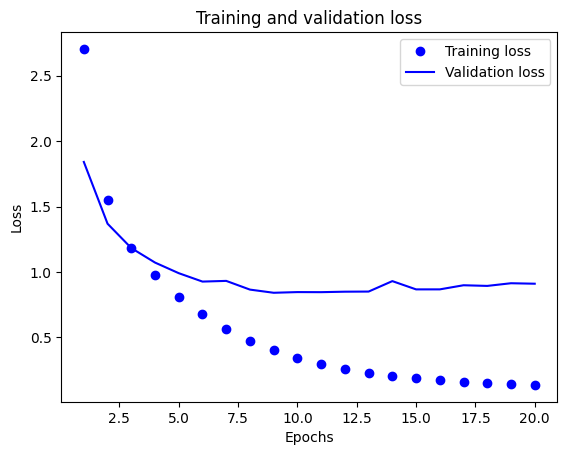

In [28]:

loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

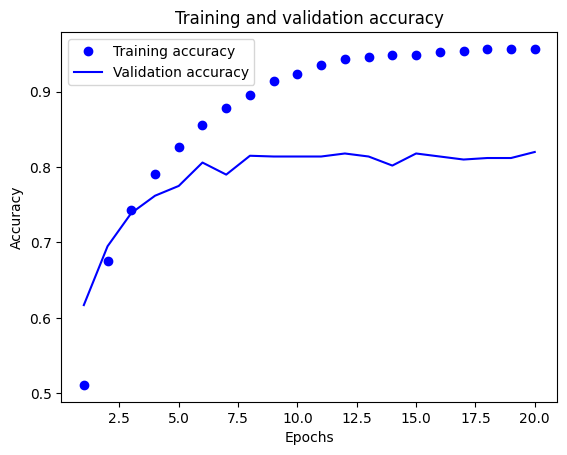

In [29]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [30]:
# overfit after 8/9 epoch

model = keras.Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")])

model.compile(optimizer="rmsprop",
loss="categorical_crossentropy",
metrics=["accuracy"])

model.fit(x_train,
          y_train,
          epochs=9,
          batch_size=512)

results = model.evaluate(x_test, y_test)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5157 - loss: 2.6510
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.6886 - loss: 1.4905
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7525 - loss: 1.1468
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.8006 - loss: 0.9388
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.8334 - loss: 0.7771
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8629 - loss: 0.6435
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8861 - loss: 0.5416
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.9039 - loss: 0.4556
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9149 - loss: 0.3868
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7956 - loss: 0.9169


In [31]:
results

[0.9169033765792847, 0.7956367135047913]

In [32]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [33]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [35]:
y_train.shape

(8982,)

In [36]:
# if the categories were encoded as numerical labels (1 to 46)
# we should use: spare categorical cross entropy
# the model arquitecture would be the same 46 output units <(probs)

model.compile(optimizer="rmsprop",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]

